## Name: GWIZA Rodrigue
## ID:101209

## Question 1: Understand the Data

The Groceries dataset was loaded as a list of transactions, where each transaction is a
list of the items purchased together in a single supermarket visit. Since the raw CSV has
no header row and a variable number of items per row (padded with empty commas), each row
was read and stripped of empty entries to reconstruct the actual item list per transaction.

In [1]:
import csv
from collections import Counter

transactions = []
with open('groceries.csv', newline='', encoding='utf-8') as f:
    reader = csv.reader(f)
    for row in reader:
        items = [item.strip() for item in row if item.strip() != '']
        transactions.append(items)

print("Loaded", len(transactions), "transactions")
transactions[:3]

Loaded 9835 transactions


[['citrus fruit', 'semi-finished bread', 'margarine', 'ready soups'],
 ['tropical fruit', 'yogurt', 'coffee'],
 ['whole milk']]

(a) number of transactions:

In [2]:
n_transactions = len(transactions)
print("Number of transactions:", n_transactions)

Number of transactions: 9835


(b) number of unique items:

In [3]:
all_items = set()
for t in transactions:
    all_items.update(t)

n_items = len(all_items)
print("Number of unique items:", n_items)

Number of unique items: 169


(c) top 10 most frequent items:

In [4]:
item_counts = Counter()
for t in transactions:
    item_counts.update(t)

top10 = item_counts.most_common(10)
for item, count in top10:
    print(f"{item}: {count}")

whole milk: 2513
other vegetables: 1903
rolls/buns: 1809
soda: 1715
yogurt: 1372
bottled water: 1087
root vegetables: 1072
tropical fruit: 1032
shopping bags: 969
sausage: 924


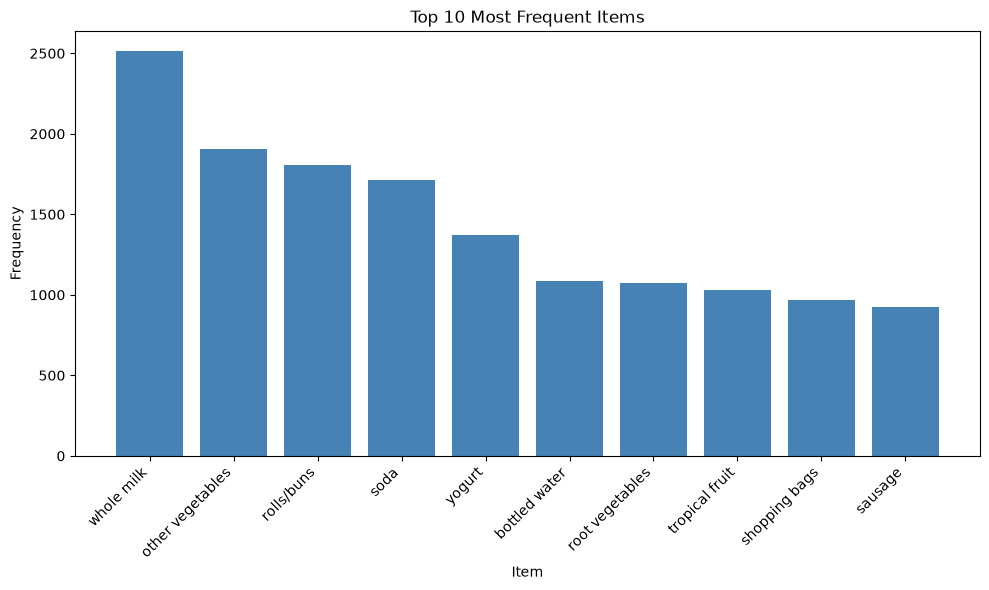

In [5]:
import matplotlib.pyplot as plt

items = [item for item, count in top10]
counts = [count for item, count in top10]

plt.figure(figsize=(10, 6))
plt.bar(items, counts, color='steelblue')
plt.xticks(rotation=45, ha='right')
plt.xlabel("Item")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Items")
plt.tight_layout()
plt.show()

## Question 2: Frequent Itemsets

Frequent itemsets were identified using the Apriori algorithm (mlxtend), with a minimum
support threshold of 0.01 (1%). This threshold was chosen deliberately low: with 169
distinct items across 9,835 transactions, most item combinations naturally occur together
in only a small fraction of transactions, so a high threshold would return zero itemsets.

one-hot encode the transactions:

In [6]:
import pandas as pd
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_onehot = pd.DataFrame(te_array, columns=te.columns_)

print("Shape:", df_onehot.shape)
df_onehot.head()

Shape: (9835, 169)


,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,baby food,bags,baking powder,bathroom cleaner,beef,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


one-hot encode the transactions:

run Apriori and filter to itemsets with 2+ items:

In [7]:
frequent_itemsets = apriori(df_onehot, min_support=0.01, use_colnames=True)
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

multi_itemsets = frequent_itemsets[frequent_itemsets['length'] >= 2].sort_values('support', ascending=False)
print("Total frequent itemsets (2+ items):", len(multi_itemsets))
multi_itemsets.head(15)

Total frequent itemsets (2+ items): 245


,support,itemsets,length
239,0.074835,"frozenset({whole milk, other vegetables})",2
267,0.056634,"frozenset({whole milk, rolls/buns})",2
300,0.056024,"frozenset({yogurt, whole milk})",2
274,0.048907,"frozenset({root vegetables, whole milk})",2
229,0.047382,"frozenset({root vegetables, other vegetables})",2
240,0.043416,"frozenset({yogurt, other vegetables})",2
228,0.042603,"frozenset({rolls/buns, other vegetables})",2
294,0.042298,"frozenset({tropical fruit, whole milk})",2
290,0.040061,"frozenset({soda, whole milk})",2
264,0.038332,"frozenset({soda, rolls/buns})",2


(a) At least 10 frequent itemsets (table above) — all found with min_support=0.01.

(b) Support values reported directly in the table (e.g., {other vegetables, whole milk} = 0.0748).

(c) The itemset with the highest support is {other vegetables, whole milk}, support = 0.0748 — meaning this pair was bought together in about 7.5% of all transactions.

(d) What support tells you about purchasing behavior: support measures how common a combination is across all shopping trips — it's a raw popularity measure, not a relationship measure. High support here (dominated entirely by "whole milk" pairings) mostly reflects that milk and vegetables are both extremely common staples individually — it doesn't yet tell you whether buying one causes or predicts buying the other (that's what confidence and lift are for, coming in Question 3).

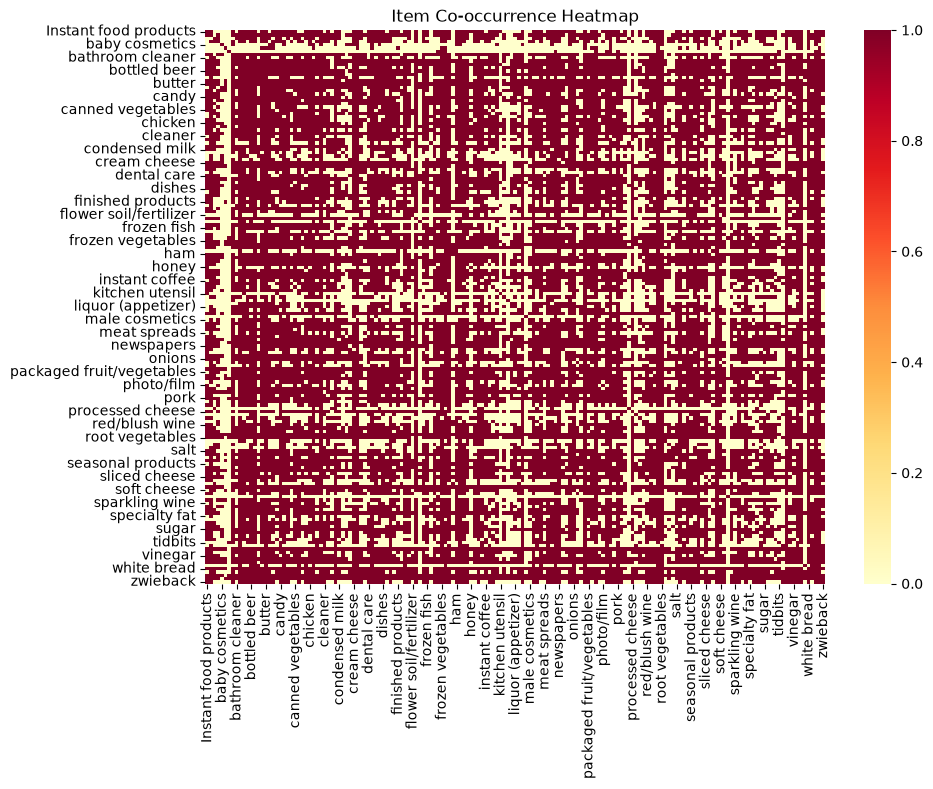

In [8]:
import seaborn as sns
import pandas as pd

cooc = df_onehot.T.dot(df_onehot)

plt.figure(figsize=(10,8))
sns.heatmap(cooc, cmap='YlOrRd')
plt.title('Item Co-occurrence Heatmap')
plt.tight_layout()
plt.show()

## Question 3: Association Rules

Association rules were generated from the frequent itemsets (Question 2) using mlxtend's
`association_rules()` function, with a minimum confidence threshold of 0.3. This produced
125 rules; the 15 with the highest confidence are reported below.

In [9]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, num_itemsets=len(df_onehot),
                           metric="confidence", min_threshold=0.3)

print("Total rules generated:", len(rules))

cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
rules_sorted = rules.sort_values('confidence', ascending=False)
rules_sorted[cols].head(15)

Total rules generated: 125


,antecedents,consequents,support,confidence,lift
73,"frozenset({root vegetables, citrus fruit})",frozenset({other vegetables}),0.010371,0.586207,3.029608
95,"frozenset({root vegetables, tropical fruit})",frozenset({other vegetables}),0.012303,0.584541,3.020999
79,"frozenset({yogurt, curd})",frozenset({whole milk}),0.010066,0.582353,2.279125
72,"frozenset({butter, other vegetables})",frozenset({whole milk}),0.011490,0.573604,2.244885
118,"frozenset({root vegetables, tropical fruit})",frozenset({whole milk}),0.011998,0.570048,2.230969
119,"frozenset({root vegetables, yogurt})",frozenset({whole milk}),0.014540,0.562992,2.203354
82,"frozenset({domestic eggs, other vegetables})",frozenset({whole milk}),0.012303,0.552511,2.162336
123,"frozenset({yogurt, whipped/sour cream})",frozenset({whole milk}),0.010880,0.524510,2.052747
115,"frozenset({root vegetables, rolls/buns})",frozenset({whole milk}),0.012710,0.523013,2.046888
88,"frozenset({other vegetables, pip fruit})",frozenset({whole milk}),0.013523,0.517510,2.025351


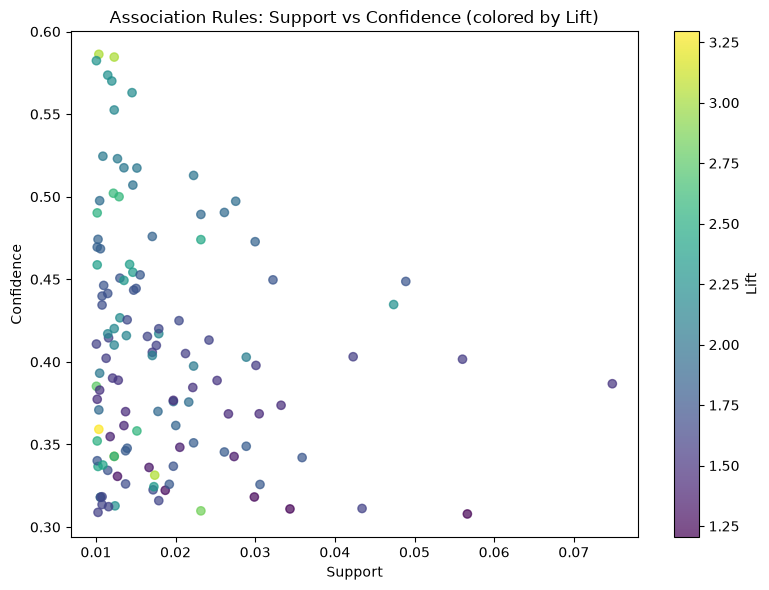

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
scatter = plt.scatter(rules['support'], rules['confidence'], c=rules['lift'], cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rules: Support vs Confidence (colored by Lift)')
plt.tight_layout()
plt.show()

## Question 4: Understanding the Measures

Three rules were selected to illustrate support, confidence, and lift:

**Rule 1:** {root vegetables, citrus fruit} → {other vegetables}
Support = 0.0104, Confidence = 0.586, Lift = 3.03

**Rule 2:** {curd, yogurt} → {whole milk}
Support = 0.0101, Confidence = 0.582, Lift = 2.28

**Rule 3:** {other vegetables} → {whole milk}
Support = 0.0748, Confidence = 0.387, Lift = 1.51

**(a) Support** measures how often the *entire* itemset (antecedent + consequent together)
appears across all transactions. Rule 3's support of 0.0748 means "other vegetables" and
"whole milk" were bought together in 7.48% of all 9,835 transactions — the highest of the
three, since both items are individually very common.

**(b) Confidence** measures, out of all transactions that already contain the antecedent,
what fraction also contain the consequent. Rule 1's confidence of 0.586 means: among
customers who bought both root vegetables and citrus fruit, 58.6% of them also bought other
vegetables.

**(c) Lift** measures how much more likely the consequent is, given the antecedent, compared
to its normal likelihood on its own. Rule 1's lift of 3.03 means customers who buy root
vegetables and citrus fruit are 3.03 times more likely to also buy other vegetables than a
random customer. Rule 3's much lower lift (1.51) shows that despite having by far the highest
support, this rule reflects a much weaker genuine relationship — whole milk is so universally
popular (bought in 25.5% of all transactions) that almost anything shows moderately high
co-occurrence with it, without a strong real connection.

Question 5: Find Interesting Rules

In [11]:
print("=== HIGHEST CONFIDENCE ===")
print(rules.loc[rules['confidence'].idxmax(), cols])

print("\n=== HIGHEST LIFT ===")
print(rules.loc[rules['lift'].idxmax(), cols])

print("\n=== HIGHEST SUPPORT ===")
print(rules.loc[rules['support'].idxmax(), cols])

=== HIGHEST CONFIDENCE ===
antecedents    frozenset({root vegetables, citrus fruit})
consequents                 frozenset({other vegetables})
support                                          0.010371
confidence                                       0.586207
lift                                             3.029608
Name: 73, dtype: object

=== HIGHEST LIFT ===
antecedents    frozenset({citrus fruit, other vegetables})
consequents                   frozenset({root vegetables})
support                                           0.010371
confidence                                        0.359155
lift                                              3.295045
Name: 74, dtype: object

=== HIGHEST SUPPORT ===
antecedents    frozenset({other vegetables})
consequents          frozenset({whole milk})
support                             0.074835
confidence                          0.386758
lift                                1.513634
Name: 53, dtype: object


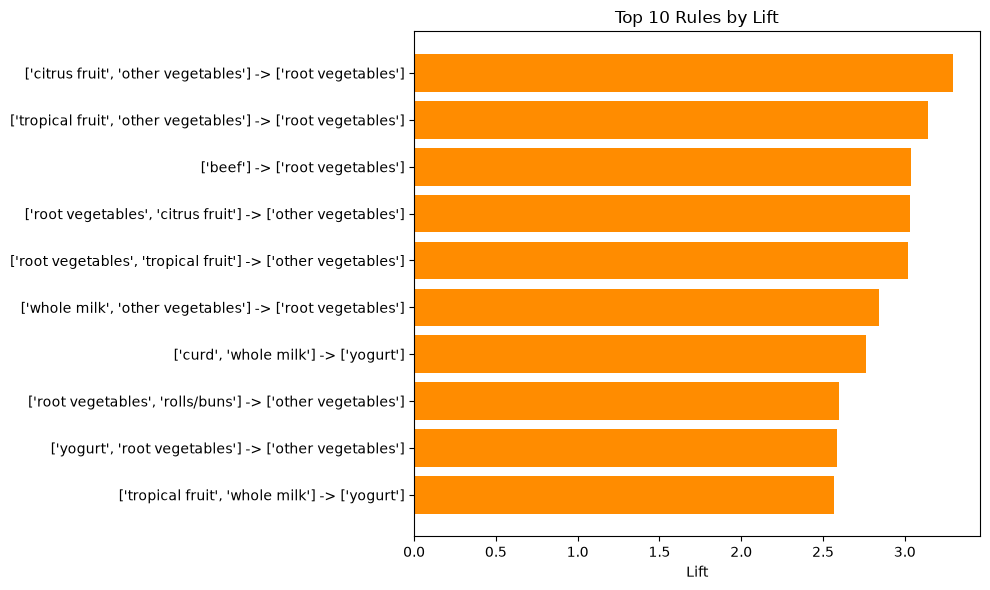

In [12]:
top_rules = rules.sort_values('lift', ascending=False).head(10)
labels = [f"{list(a)} -> {list(c)}" for a, c in zip(top_rules['antecedents'], top_rules['consequents'])]

plt.figure(figsize=(10,6))
plt.barh(labels, top_rules['lift'], color='darkorange')
plt.xlabel('Lift')
plt.title('Top 10 Rules by Lift')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

/var/folders/c9/q3bvmd6133g7rbnmb19x53tm0000gn/T/ipykernel_13462/3586899632.py:14: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


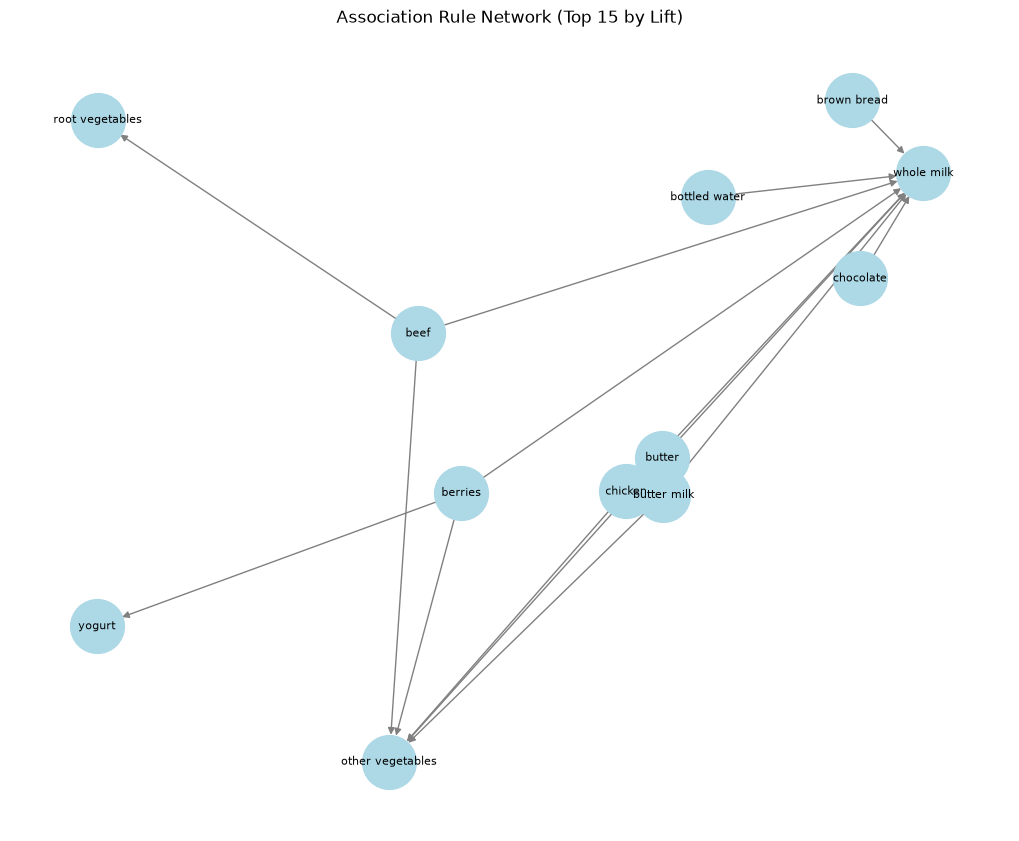

In [13]:
import networkx as nx

G = nx.DiGraph()
for _, row in rules.head(15).iterrows():
    for a in row['antecedents']:
        for c in row['consequents']:
            G.add_edge(a, c, weight=row['lift'])

plt.figure(figsize=(10,8))
pos = nx.spring_layout(G, k=0.5)
nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=1500,
        font_size=8, arrows=True, edge_color='gray')
plt.title('Association Rule Network (Top 15 by Lift)')
plt.tight_layout()
plt.show()

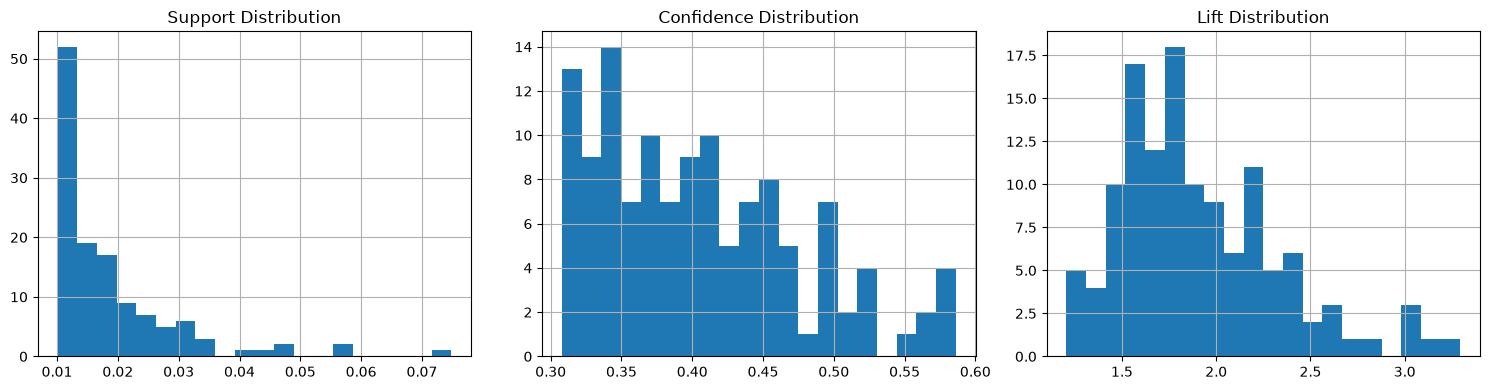

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))
rules['support'].hist(ax=axes[0], bins=20); axes[0].set_title('Support Distribution')
rules['confidence'].hist(ax=axes[1], bins=20); axes[1].set_title('Confidence Distribution')
rules['lift'].hist(ax=axes[2], bins=20); axes[2].set_title('Lift Distribution')
plt.tight_layout()
plt.show()

**(d) Are these the same rule?** No — all three are different rules. This demonstrates
that support, confidence, and lift each measure something distinct: support rewards
raw popularity, confidence rewards a strong one-directional purchase pattern, and lift
rewards a genuinely surprising relationship relative to how common the consequent already
is on its own. The highest-support rule ({other vegetables} → {whole milk}) simply
involves two extremely common items, while the highest-lift rule involves a smaller,
more specific combination that is much more strongly connected than chance would predict.

## Question 6: Interpret a Rule

**Selected rule:** {root vegetables, citrus fruit} → {other vegetables}
Support = 0.0104, Confidence = 0.586, Lift = 3.03

**In simple language:** Customers who purchase both root vegetables and citrus fruit also
tend to purchase other vegetables, in about 59% of their shopping trips.

**Strong or weak association?** This is a **strong** association. The lift of 3.03 means
this combination occurs three times more often than would be expected if the two purchases
were independent of each other — a lift this far above 1 indicates a genuine, non-random
purchasing pattern (likely reflecting a general "healthy/produce-focused" shopping trip
pattern), not coincidence.

## Question 7: Business Application

**(a) Two products to place close together:** Root vegetables and other vegetables — their
pairwise rule ({root vegetables} → {other vegetables}) shows strong lift, and placing them
in adjacent shelving would match how customers already shop.

**(b) Possible product bundle:** A "vegetable basket" bundle combining root vegetables,
citrus fruit, and other vegetables — directly reflecting the highest-confidence rule found
in Question 5, where 58.6% of customers who bought the first two items also bought the third.

**(c) Recommendation system example:** When a customer's online cart or basket already
contains root vegetables and citrus fruit, the store's recommendation system could
automatically suggest other vegetables, since historical data shows a 58.6% chance the
customer will want them too — directly operationalizing the rule discovered above.

## Question 8: Understanding Association

**(a) Does an association rule prove causation?** No. An association rule only shows that
two items were frequently purchased together in the historical data — it says nothing about
*why*. Buying root vegetables does not cause someone to buy other vegetables; both purchases
more likely stem from a shared underlying cause, such as a general preference for
vegetable-heavy meals. This is the same principle as "correlation does not imply causation."

**(b) Why might a rule have high confidence but low lift?** This happens when the consequent
item is already extremely popular on its own, regardless of the antecedent. For example, the
rule {berries} → {whole milk} has a confidence of 0.355 (35.5% of berry-buyers also buy
milk), but its lift is only 1.39 — barely above 1. This is because whole milk alone already
appears in 25.5% of all transactions, so a 35.5% co-occurrence rate isn't actually much
higher than what random chance would produce. High confidence alone can be misleading if the
consequent is simply a universally popular item.

**(c) What does a lift value greater than 1 indicate?** A lift greater than 1 means the two
items are purchased together more often than would be expected if they were completely
independent — a positive, genuine association. A lift of exactly 1 would mean no relationship
at all (pure chance), and a lift below 1 would mean the items are actually purchased together
*less* than chance would predict (a negative association — buying one makes the other less
likely).